# Importation des bibliothèques nécessaires


In [3]:
import pandas as pd
import numpy as np
from ast import literal_eval
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import csr_matrix, hstack
import matplotlib.pyplot as plt
import seaborn as sns


# Configuration de l'affichage 


In [5]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)


## 1. Chargement et exploration des données


# Chargement du dataset


In [8]:
df = pd.read_csv('dataset_etudiants.csv')


# Affichage des premières lignes 


In [10]:
# Conversion des colonnes avec listes
from ast import literal_eval
import pandas as pd

list_columns = ['Coéquipiers', 'Communautés', 'Compétences', 'Centres_d\'Intérêt']
for col in list_columns:
    df[col] = df[col].apply(
        lambda x: literal_eval(x) if isinstance(x, str) and x.strip() not in ['', 'nan', 'NaN'] else []
    )

In [15]:
# Statistiques descriptives
print("\nStatistiques descriptives:")
print(df.describe())


Statistiques descriptives:
       ID_Étudiant  Travaux_Collaboratifs  Nombre_Interactions
count     50.00000              50.000000            50.000000
mean      25.50000               5.200000            57.560000
std       14.57738               2.899683            27.422737
min        1.00000               1.000000             7.000000
25%       13.25000               2.250000            34.250000
50%       25.50000               5.000000            64.000000
75%       37.75000               8.000000            81.750000
max       50.00000              10.000000           100.000000


# 2. Création des caractéristiques


In [18]:
mlb = MultiLabelBinarizer()
competences_matrix = csr_matrix(mlb.fit_transform(df['Compétences']))
interets_matrix = csr_matrix(mlb.fit_transform(df['Centres_d\'Intérêt']))
communautes_matrix = csr_matrix(mlb.fit_transform(df['Communautés']))

scaler = MinMaxScaler()
numerical_features = csr_matrix(scaler.fit_transform(df[['Travaux_Collaboratifs', 'Nombre_Interactions']]))

# 3. Combinaison des caractéristiques


In [21]:
final_matrix = hstack([
    competences_matrix,
    interets_matrix,
    communautes_matrix,
    numerical_features
])

# 4. Réduction de dimension avec SVD


In [24]:
n_components = min(10, final_matrix.shape[1] - 1)  # S'assurer que n_components est valide
svd = TruncatedSVD(n_components=n_components)
reduced_matrix = svd.fit_transform(final_matrix)


# 5. Calcul de la variance expliquée


Variance expliquée par les 10 composantes : 77.34%


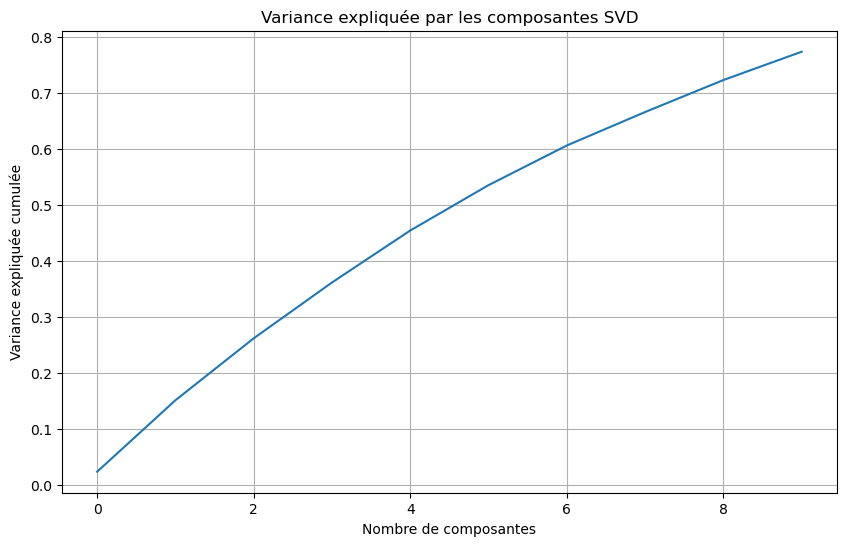


Dimensions de reduced_matrix: (50, 10)
Calcul des similarités réussi!


In [31]:
# Import manquant nécessaire
from sklearn.metrics.pairwise import cosine_similarity

# [...] (le reste de vos imports)

# 4. Réduction de dimension avec SVD (partie existante)
n_components = min(10, final_matrix.shape[1] - 1)
svd = TruncatedSVD(n_components=n_components)
reduced_matrix = svd.fit_transform(final_matrix)  # Assurez-vous que cette ligne est bien présente

# 5. Analyse de variance (partie existante)
explained_variance = svd.explained_variance_ratio_.sum()
print(f"Variance expliquée par les {n_components} composantes : {explained_variance:.2%}")

# Visualisation (partie existante)
plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(svd.explained_variance_ratio_))
plt.xlabel('Nombre de composantes')
plt.ylabel('Variance expliquée cumulée')
plt.title('Variance expliquée par les composantes SVD')
plt.grid()
plt.show()

# 6. Calcul des similarités 
try:
    # Vérification que reduced_matrix existe et a la bonne forme
    if 'reduced_matrix' not in locals():
        raise NameError("reduced_matrix n'est pas défini")
    
    print(f"\nDimensions de reduced_matrix: {reduced_matrix.shape}")  # Debug
    
    cosine_sim_svd = cosine_similarity(reduced_matrix)
    print("Calcul des similarités réussi!")
    
except NameError as e:
    print(f"\nERREUR: {e}")
    print("Veuillez vérifier que:")
    print("1. Tous les imports sont présents")
    print("2. reduced_matrix est bien calculé")
    print("3. cosine_similarity est importé")
except Exception as e:
    print(f"\nERREUR inattendue: {e}")

# 7. Fonction de recommandation


In [34]:
def recommander_etudiants(nom_etudiant, matrice_similarite, df, n_recommandations=5):
    """
    Retourne les étudiants les plus similaires à l'étudiant spécifié
    
    Args:
        nom_etudiant (str): Nom de l'étudiant de référence
        matrice_similarite (np.array): Matrice de similarité cosinus
        df (pd.DataFrame): DataFrame contenant les données des étudiants
        n_recommandations (int): Nombre de recommandations à retourner
    
    Returns:
        pd.DataFrame: DataFrame contenant les étudiants recommandés
    """
    idx = df[df['Nom'] == nom_etudiant].index[0]
    scores_similarite = list(enumerate(matrice_similarite[idx]))
    scores_similarite = sorted(scores_similarite, key=lambda x: x[1], reverse=True)
    scores_similarite = scores_similarite[1:n_recommandations+1]  # Exclure l'étudiant lui-même
    
    indices_recommandations = [i[0] for i in scores_similarite]
    scores = [i[1] for i in scores_similarite]
    
    recommandations = df.iloc[indices_recommandations][['Nom', 'Compétences', 'Centres_d\'Intérêt', 'Communautés']]
    recommandations['Score_Similarite'] = scores
    
    return recommandations


# 8. Test du système


In [37]:
print("\nTest du système de recommandation...")
etudiant_test = 'Etudiant_1'
print(f"\nRecommandations pour {etudiant_test}:")
recommandations = recommander_etudiants(etudiant_test, cosine_sim_svd, df)
print(recommandations)


Test du système de recommandation...

Recommandations pour Etudiant_1:
            Nom                      Compétences  \
21  Etudiant_22                 [IA, Blockchain]   
23  Etudiant_24  [Blockchain, Design, Marketing]   
48  Etudiant_49       [Data Science, Blockchain]   
27  Etudiant_28                   [Data Science]   
1    Etudiant_2         [IA, Blockchain, Python]   

                        Centres_d'Intérêt                      Communautés  \
21  [Musique, Hackathon, Entrepreneuriat]      [Groupe IA, Club Robotique]   
23                           [Jeux vidéo]      [Club Robotique, Groupe IA]   
48      [Jeux vidéo, Hackathon, Écologie]      [Groupe IA, Club Robotique]   
27                    [Écologie, Musique]                      [Groupe IA]   
1                               [Musique]  [Club Entrepreneurs, Groupe IA]   

    Score_Similarite  
21          0.782276  
23          0.755666  
48          0.752690  
27          0.739737  
1           0.737998  


# 9. Sauvegarde du modèle (optionnel)


In [40]:
import pickle
print("\nSauvegarde du modèle...")
with open('modele_recommandation.pkl', 'wb') as f:
    pickle.dump({
        'svd': svd,
        'mlb': mlb,
        'scaler': scaler,
        'noms_etudiants': df['Nom'].values
    }, f)

print("\nSystème de recommandation prêt à l'emploi!")


Sauvegarde du modèle...

Système de recommandation prêt à l'emploi!
